***

# MACP 技术架构与工程实现指南
> **—— 从愿景到代码的落地蓝图**

## 1. 引言：用什么技术支撑我们的愿景？

在《MACP 白皮书》中，我们提出了一个具备**“规划-生成-评估-沉淀”**能力的协同进化引擎。为了让这些虚拟的 AI 角色（TM、SG、Eva）真正跑起来，并且实现**“随时让人类介入”**、**“无限次打磨修改”**以及**“沉淀数字资产”**，我们采用了一套现代化的大模型应用技术栈。

本文档旨在为研发团队明确：我们到底用了哪些核心技术？它们是用来干什么的？以及在我们的 MACP 项目中具体扮演什么角色。

---

## 2. 核心技术栈详解：它是干啥的？怎么用？

### 2.1 LangGraph (核心状态与工作流引擎)
* **这是什么？**
  传统的 AI 是一条直线（问 $\rightarrow$ 答），而 LangGraph 是一个允许构建**“循环图（Graph）”**的框架。它能让 AI 的工作流像状态机一样运转，支持复杂的条件判断、循环往复，并且能记住每一步的“状态（State）”。
* **在 MACP 中怎么用？（系统的骨架）**
  * **构建循环与打磨 (StateGraph & Conditional Edge)：** 这是实现 `SG ↔ Eva` 反射进化的底座。当 Eva 觉得 SG 写的教案不合格时，LangGraph 的“条件边”会将流程重新指回 SG，形成循环，直到评估通过。
  * **人类介入 (Human-in-the-Loop & Interrupt)：** 在 TM（AI 教务总监）拆解完任务后，LangGraph 可以触发 Interrupt 暂停整个流程。系统停下等待人类讲师确认大纲，人类修改完毕后，系统再继续往下跑。
  * **多方案并发 (Parallel Branches)：** 当我们需要 SG 同时生成 3 套不同的讲解方案时，LangGraph 的并行分支能力可以让 3 个生成任务同时触发，极大提升响应速度。
  * **记忆存档 (Checkpoint)：** 它可以把运行到一半的图状态存入数据库（如 SQLite）。即使系统重启，也能从上一次人类中断的地方继续运行。

### 2.2 MCP (Model Context Protocol 模型上下文协议)
* **这是什么？**
  如果说大模型是“大脑”，MCP 就是标准化的**“USB 接口”**。它是 Anthropic 推出的一种开源协议，让 AI 可以安全、统一地连接外部的工具（Tools）、数据源（Resources）和文件系统。
* **在 MACP 中怎么用？（数字资产的搬运工）**
  * **统一的工具调用 (Tool Calling)：** SG 生成包含代码、文本的复杂教案时，通过 MCP 协议调用“代码沙盒工具”进行测试，调用“绘图工具”生成图表。
  * **消除“阅后即焚”，实现资产沉淀：** 这是 MACP 的**核心护城河**。当 Eva 验证通过一份产物后，系统调用 MCP 的 Filesystem（文件系统）或存储接口，将高价值的 Artifacts（如优质教案 Markdown、图片、代码片段）永久保存到共享库中，供下一次任务直接检索复用。

### 2.3 Vector DB (向量数据库) & RAG (检索增强生成)
* **这是什么？**
  向量数据库（如 Qdrant / Pinecone）是用来存储“语义”的数据库。RAG 则是让 AI 在回答问题前，先去这个数据库里“翻书找资料”的技术。
* **在 MACP 中怎么用？（团队的公共知识库）**
  * 配合 MCP 沉淀下来的数字资产，需要被“找得到”。我们会将历史优质教案转化为向量存入 Vector DB。当有新的老师需要一节相似课程时，TM 和 SG 会通过 RAG 技术，瞬间回忆起“我们之前做过一份类似的高分图表”，直接提取复用，拒绝重复造轮子。

### 2.4 可观测性工具 (LangSmith / Langfuse)
* **这是什么？**
  是大模型应用的“监控摄像头”和“行车记录仪”。它能记录下 AI 每一步到底想了什么、花了多少时间、消耗了多少 Token（钱）。
* **在 MACP 中怎么用？（防止 AI 宕机与成本失控）**
  * 多智能体循环（`SG ↔ Eva`）最怕的就是“死循环”（双方互相不认同，无限重试）。通过这些监控工具，我们可以追踪每一个循环的耗时，设定最大迭代次数，并且监控整体 API 成本。

---

## 3. 团队人员分工与技术栈映射

MACP 是一个纯后端驱动、高度解耦的协同系统。团队 5 人的分工严格遵循**“接口契约先行”**，每个人负责不同的智能体或基建节点。

### 👩‍💻 Person A (架构 Owner：系统大脑与总协调)
* **核心职责：** 设计系统最核心的数据结构，把控整体 LangGraph 运行流转。
* **涉及技术点：**
  * **LangGraph Core：** 构建全局 State Schema（用 Pydantic 定义数据格式），编写主图（Main Graph）的流转逻辑。
  * **Checkpoint & State：** 配置 SQLite/Postgres 等状态持久化方案。
  * **系统胶水：** 定义 A2A（智能体间）通信协议，确保 TM、SG、Eva 之间的数据能正确流转。

### 🧑‍💻 Person B (TM 模块研发：教务总监的缔造者)
* **核心职责：** 实现 TM (Task Manager) 的逻辑，负责任务的接收、拆解以及与人类的交互。
* **涉及技术点：**
  * **LangGraph Interrupt：** 实现系统中断，对接 Human-in-the-Loop 的交互逻辑。
  * **Prompt Engineering：** 编写高级 Prompt，让 TM 能精准理解模糊需求并拆解为 Subtasks。
  * **数据聚合：** 利用 LangGraph 节点处理各个 SG 汇总回来的多方案数据，进行最终整合。

### 👨‍💻 Person C (SG 模块研发：多模态干活主力的缔造者)
* **核心职责：** 实现 SG (Solution Generator)，让其能够并发生成多种方案（文本/代码/图表）。
* **涉及技术点：**
  * **多模态 LLM 调用：** 熟悉各类大模型接口（支持文本与图片生成）。
  * **LangGraph 并行分支：** 使用图的并行能力，同时生成 $K$ 个不同的候选方案。
  * **MCP 客户端重度使用：** 调用 MCP 提供的工具（Tools），如沙盒执行代码，并在生成完毕后，调用 MCP 接口把结果（Artifacts）妥善保存。

### 👩‍🔧 Person D (Eva 模块研发：严苛质检员的缔造者)
* **核心职责：** 实现 Eva 评估器，对 SG 生成的产物进行质量控制和打分。
* **涉及技术点：**
  * **LangGraph 循环控制 (Reflection Loop)：** 编写评估后的路由逻辑——如果分数低于阈值，将状态重置并打回给 SG；如果达标，放行至下一环。
  * **MCP 数据读取：** 通过 MCP 协议读取 SG 刚生成的文件或代码，进行独立审查。
  * **评估器 Prompt 与排序算法：** 编写“打分板 (Rubric)” Prompt，以及在多个方案中“择优录取”的逻辑。

### 👨‍🏭 Person E (基础设施与基建：为团队造兵工厂)
* **核心职责：** 不写具体的 AI 业务逻辑，只负责搭建底层服务平台和持久化存储。
* **涉及技术点：**
  * **MCP Server 搭建：** 为全队提供统一的外部能力接口（封装文件系统操作、外部 API 调用等）。
  * **Vector DB & Memory：** 部署 Qdrant/Pinecone，搭建基于长文本与记忆的 Mem0/Zep 存储层。
  * **DevOps & 监控：** 接入 LangSmith/Langfuse 追踪数据，搭建 Docker 容器化环境和 Pytest 测试框架。

---

### 💡 协作准则

Person A 定义好 State（数据字典）后，所有人基于此字典开始并行开发各自的节点。Person E 提供的 MCP Server 是 Person B/C/D 操作外部文件的唯一合法途径。

> *“大家就像在拼装一个精密的钟表，通过 LangGraph 将各自的齿轮咬合在一起。”*

### 这个很多技术我也是第一次接触，如果有问题，大家可以指出来，我们一起改进  
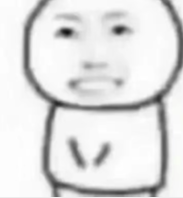